# Capstone: Define and Solve an ML Problem

In [1]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

**Note**: As you work through the notebook, you can import additional packages as needed.

## Overview


In this capstone assignment, you will follow the machine learning life cycle and implement one of the supervised learning models you have learned so far in this course, along with a neural network, to solve a predictive problem.

This capstone spans two lab sessions.

- **Unit 5 Lab:** You will define a machine learning problem, explore and prepare your data, and train, test, evaluate and improve a traditional machine learning model (Parts 1–5).
- **Unit 6 Lab:** After completing Unit 6 on neural networks, you will apply a neural network to the same problem and compare the two approaches (Parts 6–7).

There is a checkpoint at the end of Part 5 that marks where to stop during the Unit 5 lab.

You will complete the following:

1. Choose your Data Set and Build Your DataFrame
2. Define Your ML Problem
3. Understand Your Data
4. Prepare Your Data
5. Train, Test, Evaluate and Improve a Traditional Machine Learning Model *(Unit 5 lab)*
6. Train, Test, Evaluate and Improve Neural Network *(Unit 6 lab)*
7. Compare Your Models and Reflect *(Unit 6 lab)*

**This is an individual assignment.** You are welcome to discuss ideas with your peers, but the code and written responses you submit must be your own.

**Note:** This capstone is intentionally less scaffolded than your weekly labs; that is by design. You are expected to make your own implementation choices, add code cells as needed, and document your reasoning throughout.

## Part 1: Choose Your Data Set and Build Your DataFrame


You will choose one of two data sets to work with for this capstone. In both cases, you will be solving a supervised learning binary classification problem by predicting one of two possible class labels. Both data sets have been used earlier in the course, so you are already familiar with their structure. 

**Option A: Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. You will use it to predict whether an individual's annual income exceeds $50,000. Your label column is `income_binary`, which contains two values: `<=50K` and `>50K`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Option B: Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. You will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Note:**  These versions of the data sets differ slightly from the versions you have worked with in this program. For example, they may not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for the two data sets available to you.

<b>Task:</b> In the code cell below, load your chosen data set using `pd.read_csv()` and save it to a DataFrame named `df`. Then call `df.head()` to inspect the first few row of the data set.

In [2]:
# File paths for both data sets
census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData.csv")
airbnb_filename = os.path.join(os.getcwd(), "data_capstone", "airbnbListingsData.csv")

# Load your chosen dataset and save it to df
df = pd.read_csv(airbnb_filename)

df.head()

,name,description,neighborhood_overview,host_name,host_location,host_about,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,...,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,n_host_verifications,price_category
0,Skylit Midtown Castle,"Beautiful, spacious skylit studio in the heart...",Centrally located in the heart of Manhattan ju...,Jennifer,"New York, New York, United States",A New Yorker since 2000! My passion is creatin...,0.80,0.17,True,8.0,...,4.86,4.41,False,3,3,0,0,0.33,9,low
1,"Whole flr w/private bdrm, bath & kitchen(pls r...","Enjoy 500 s.f. top floor in 1899 brownstone, w...",Just the right mix of urban center and local n...,LisaRoxanne,"New York, New York, United States",Laid-back Native New Yorker (formerly bi-coast...,0.09,0.69,True,1.0,...,4.71,4.64,False,1,1,0,0,4.86,6,low
2,"Spacious Brooklyn Duplex, Patio + Garden",We welcome you to stay in our lovely 2 br dupl...,NaN,Rebecca,"Brooklyn, New York, United States","Rebecca is an artist/designer, and Henoch is i...",1.00,0.25,True,1.0,...,4.50,5.00,False,1,1,0,0,0.02,3,high
3,Large Furnished Room Near B'way,Please don’t expect the luxury here just a bas...,"Theater district, many restaurants around here.",Shunichi,"New York, New York, United States",I used to work for a financial industry but no...,1.00,1.00,True,1.0,...,4.87,4.36,False,1,0,1,0,3.68,4,low
4,Cozy Clean Guest Room - Family Apt,"Our best guests are seeking a safe, clean, spa...",Our neighborhood is full of restaurants and ca...,MaryEllen,"New York, New York, United States",Welcome to family life with my oldest two away...,NaN,NaN,True,1.0,...,4.94,4.92,False,1,0,1,0,0.87,7,low


## Part 2: Define Your ML Problem

The first step of the machine learning life cycle involves defining your business problem. In the markdown cell below, you will clearly define what you are trying to predict and why it matters. 

<b>Task</b>: In the markdown cell below, answer all of the following questions:

1. Which data set did you choose?
2. What is your label? What are you predicting?
3. What features do you plan to use? (This list may change after you explore your data.)
5. Why does this problem matter? Using the business brief you read in the lab overview page, explain how the organization described there could use a model that predicts this label to create value or inform decisions for their client.

## Part 3: Understand Your Data

Now that you have defined your problem, perform exploratory data analysis (EDA) with that problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance


2. What machine learning model would you like to use that is suitable for your predictive problem and data?
   * You may use one of the following models that you have worked with so far:
        - K-Nearest Neighbors (KNN)
        - Decision Tree
        - Logistic Regression
   * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 

3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics or methods that are appropriate for your problem, dataset, or selected model?
    
<b>Task</b>: In the code cells below, use the techniques you have learned in this course to inspect and analyze your data.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

### Class Imbalance

Examine the distribution of your label column to determine whether class imbalance is present. Use at least one visualization to show the class distribution. In the **EDA Summary** below, you will discuss how you plan to address any observed imbalance during data preparation.

<AxesSubplot:xlabel='price_category', ylabel='Count'>

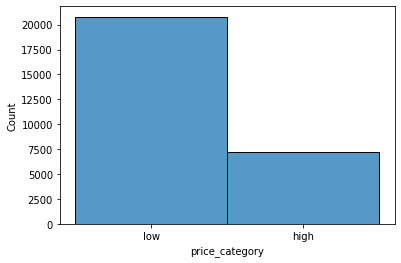

In [3]:
sns.histplot(data=df['price_category'])

### Inspect and Analyze Your Data

Explore your features. Use summary statistics and visualizations to understand how your features are distributed and how they relate to the label. Identify issues such as missing values, outliers, or a feature that is irrelevant or redundant.

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. 

Use at least one plot that visualizes a relationship between features and the label.

In [4]:
df.describe()


,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,n_host_verifications
count,16179.000000,16909.000000,28022.000000,28022.000000,28022.000000,28022.000000,25104.000000,26668.000000,28022.000000,28022.000000,...,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000
mean,0.906901,0.791953,14.554778,14.554778,2.874491,1.142174,1.329708,1.629556,154.228749,18.689387,...,4.814300,4.808041,4.750393,4.647670,9.581900,5.562986,3.902077,0.048283,1.758325,5.169510
std,0.227282,0.276732,120.721287,120.721287,1.860251,0.421132,0.700726,1.097104,140.816605,25.569151,...,0.438603,0.464585,0.415717,0.518023,32.227523,26.121426,17.972386,0.442459,4.446143,2.028497
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,29.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.010000,1.000000
25%,0.940000,0.680000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,70.000000,2.000000,...,4.810000,4.810000,4.670000,4.550000,1.000000,0.000000,0.000000,0.000000,0.130000,4.000000
50%,1.000000,0.910000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,115.000000,30.000000,...,4.960000,4.970000,4.880000,4.780000,1.000000,1.000000,0.000000,0.000000,0.510000,5.000000
75%,1.000000,1.000000,3.000000,3.000000,4.000000,1.000000,1.000000,2.000000,180.000000,30.000000,...,5.000000,5.000000,5.000000,5.000000,3.000000,1.000000,1.000000,0.000000,1.830000,7.000000
max,1.000000,1.000000,3387.000000,3387.000000,16.000000,8.000000,12.000000,21.000000,1000.000000,1250.000000,...,5.000000,5.000000,5.000000,5.000000,421.000000,308.000000,359.000000,8.000000,141.000000,13.000000


In [5]:
df.dtypes

name                                             object
description                                      object
neighborhood_overview                            object
host_name                                        object
host_location                                    object
host_about                                       object
host_response_rate                              float64
host_acceptance_rate                            float64
host_is_superhost                                  bool
host_listings_count                             float64
host_total_listings_count                       float64
host_has_profile_pic                               bool
host_identity_verified                             bool
neighbourhood_group_cleansed                     object
room_type                                        object
accommodates                                      int64
bathrooms                                       float64
bedrooms                                        

<AxesSubplot:xlabel='price_category', ylabel='accommodates'>

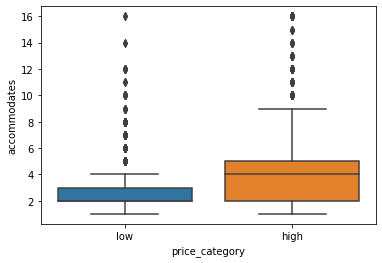

In [6]:
sns.boxplot(data = df, x='price_category', y='accommodates')

<AxesSubplot:>

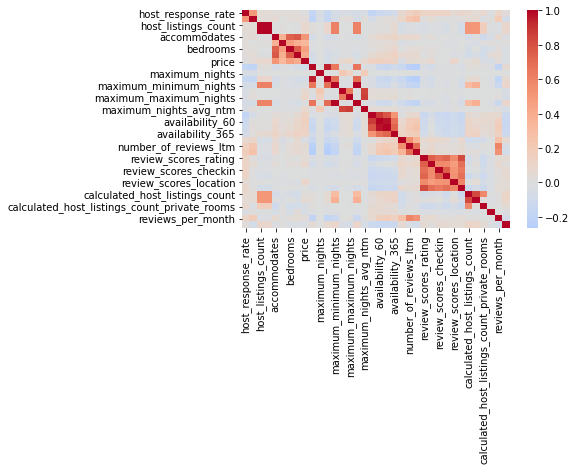

In [7]:
sns.heatmap(df.select_dtypes(include=['int64', 'float64']).corr(), cmap="coolwarm",center=0)


In [8]:
 df.select_dtypes(include=['int64', 'float64']).corr()['price'].sort_values(ascending=False)

price                                           1.000000
accommodates                                    0.519057
bedrooms                                        0.475506
beds                                            0.409236
bathrooms                                       0.331297
availability_60                                 0.152750
availability_90                                 0.148228
availability_30                                 0.146895
availability_365                                0.123984
maximum_maximum_nights                          0.107901
review_scores_location                          0.096610
maximum_nights_avg_ntm                          0.081589
review_scores_cleanliness                       0.081402
host_listings_count                             0.080995
host_total_listings_count                       0.080995
minimum_maximum_nights                          0.064011
number_of_reviews_ltm                           0.053944
calculated_host_listings_count_

In [9]:
 df.select_dtypes(include=['int64', 'float64']).corr()['price'].abs().sort_values(ascending=True)

review_scores_communication                     0.000590
maximum_nights                                  0.001024
review_scores_checkin                           0.004051
review_scores_value                             0.004761
host_response_rate                              0.006480
maximum_minimum_nights                          0.007691
minimum_nights_avg_ntm                          0.011273
calculated_host_listings_count                  0.020270
n_host_verifications                            0.024597
reviews_per_month                               0.030817
number_of_reviews                               0.033492
host_acceptance_rate                            0.037550
calculated_host_listings_count_shared_rooms     0.044391
calculated_host_listings_count_private_rooms    0.044941
review_scores_rating                            0.045067
number_of_reviews_l30d                          0.045467
calculated_host_listings_count_entire_homes     0.053687
number_of_reviews_ltm          

In [10]:
df.isna().sum()

name                                                5
description                                       570
neighborhood_overview                            9816
host_name                                           0
host_location                                      60
host_about                                      10945
host_response_rate                              11843
host_acceptance_rate                            11113
host_is_superhost                                   0
host_listings_count                                 0
host_total_listings_count                           0
host_has_profile_pic                                0
host_identity_verified                              0
neighbourhood_group_cleansed                        0
room_type                                           0
accommodates                                        0
bathrooms                                           0
bedrooms                                         2918
beds                        

### EDA Summary

<b>Task</b>: In the markdown cell below, summarize the key findings from your data exploration. Describe any patterns, anomalies, or data quality issues you identified and explain how those findings may influence your data preparation decisions. For example, your exploration may affect how you handle missing values, address class imbalance, or determine which features to keep or remove.

There is a lot of class inbalance, with "low" values greatly exceeding "high" values for price_category. The highest correlations with price are: accommodates,bedrooms,beds, bathrooms. The columns with the highest null values are host_about, host_response_rate                             , and host_acceptance_rate 

### Ethical Considerations:

Machine learning models can cause harm when they reflect or amplify biases in the data they are trained on. 

<b>Task</b>: In the markdown cell below, answer both of the following questions:

1. What biases or ethical concerns might be present in your dataset? Think about who collected the data, how it was collected, and which groups of people appear in it. Are there features in the dataset that could serve as proxies for protected characteristics like race, gender, or socioeconomic status?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how? Be specific about which groups are most at risk and what the real-world consequences of errors might look like.

1. Bias may be concerned with socioeconomic status when it comes with locations that may have a trend of economic and historical patterns.
2. Neighborhoods with historically underrepresented or undervalued properties may be affected, and properties that should be valued higher may be impacted leading to de-prioritization of properties in that area.

## Part 4: Prepare Your Data

<b>Task</b>: In the code cell below, prepare your data for modeling. The specific steps you take will depend on what you found during your EDA and which model you plan to use. 

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [11]:
df['price_category'] = df['price_category'].map({'low': 0, 'high':1})

In [22]:
enc = OneHotEncoder(sparse=False)
df_encoded = pd.DataFrame(enc.fit_transform(df[['neighbourhood_group_cleansed']]),columns=enc.get_feature_names(['neighbourhood_group_cleansed']))
df.drop(columns=['neighbourhood_group_cleansed'], inplace=True)
df = pd.concat([df, df_encoded], axis=1)

KeyError: "None of [Index(['neighbourhood_group_cleansed'], dtype='object')] are in the [columns]"

In [23]:
df = df[['price_category',
         'review_scores_cleanliness',
         'review_scores_location',
         'availability_60',
         'bathrooms',
         'beds',
         'bedrooms',
         'accommodates',
         'room_type',
         'host_is_superhost', 'host_listings_count']]

KeyError: "['room_type', 'host_is_superhost'] not in index"

In [24]:
enc = OneHotEncoder(sparse=False)
df_encoded = pd.DataFrame(enc.fit_transform(df[['room_type']]),columns=enc.get_feature_names(['room_type']))
df.drop(columns=['room_type'], inplace=True)
df = pd.concat([df, df_encoded], axis=1)

KeyError: "None of [Index(['room_type'], dtype='object')] are in the [columns]"

In [25]:
enc = OneHotEncoder(sparse=False)
df_encoded = pd.DataFrame(enc.fit_transform(df[['host_is_superhost']]),columns=enc.get_feature_names(['host_is_superhost']))
df.drop(columns=['host_is_superhost'], inplace=True)
df = pd.concat([df, df_encoded], axis=1)

KeyError: "None of [Index(['host_is_superhost'], dtype='object')] are in the [columns]"

In [26]:
df.dtypes


price_category                 int64
review_scores_cleanliness    float64
review_scores_location       float64
availability_60                int64
bathrooms                    float64
beds                         float64
bedrooms                     float64
accommodates                   int64
host_listings_count          float64
room_type_Entire home/apt    float64
room_type_Hotel room         float64
room_type_Private room       float64
room_type_Shared room        float64
host_is_superhost_True       float64
dtype: object

In [27]:

df['bathrooms'].fillna(df['bathrooms'].mean(), inplace=True)
df['bedrooms'].fillna(df['bedrooms'].mean(), inplace=True)
df['beds'].fillna(df['beds'].mean(), inplace=True)
df.isna().sum()


price_category               0
review_scores_cleanliness    0
review_scores_location       0
availability_60              0
bathrooms                    0
beds                         0
bedrooms                     0
accommodates                 0
host_listings_count          0
room_type_Entire home/apt    0
room_type_Hotel room         0
room_type_Private room       0
room_type_Shared room        0
host_is_superhost_True       0
dtype: int64

### Data Preparation Summary:

<b>Task</b>: In the markdown cell below, document the data preparation steps you took. For each decision, explain why you made it. For example, why did you handle missing values the way you did? Why did you keep or remove certain features? If a preparation step depends on the model you selected (for example, scaling for KNN but not for a decision tree), explain that as well.

I one-hot encoded categorical values so that they could used in a logistic regression model. I removed all the features that were not relavent or could not be easily one-hot encoded, as well as identifying data and data that might skew the model (e.g. maximum nights have much more weight than the one-hot encoded 0/1 columns). I filled all null values with the mean value, so listings not specifying bathroom/bedroom number will automatically be loaded with the average number of bathroom/bedrooms in an airbnb. 

## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

Now you will train, test and evaluate your model. You will also use model selection techniques to improve your model's performance by identifying the optimal hyperparameter configuration.

<b>Task</b>: In the code cells below, do the following:

1. Create labeled examples from the dataset
2. Create training and test sets out of the labeled examples 
3. Train, test and evaluate your model 
    * You must evaluate your model using accuracy and F1 score. Use `accuracy_score` and `f1_score` from `sklearn.metrics`. For the F1 score, use `average='binary'` since this is a binary classification problem. You will compare your model's performance to that of a neural network later in this capstone. Save the results of your evaluation metrics to variables for later comparison.
    * You may use additional evaluation metrics of your choosing.
4. Perform model selection through grid search cross-validation to identify optimal hyperparameter values for your model
5. Train, test and evaluate a final version of your model using the optimal hyperparameter configuration.
6. Interpret your model's outputs in the context of the business problem. Depending on the model you chose, this might mean:
    * KNN: Describe what your model's performance metrics tell you about its behavior. For example: How does accuracy change as you vary k? What does that suggest about the structure of your data?
    * Decision Tree: print or plot feature importances.
    * Logistic Regression: print or plot the model coefficients.



<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [28]:
# Create labeled examples from the dataset
y = df['price_category']
X=df.drop(columns=['price_category'])

In [29]:

# Create training and test sets out of the labeled examples 
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 123)



In [30]:
# Train, test and evaluate your model
model = LogisticRegression(C = 1, max_iter = 1000, class_weight='balanced')
model.fit(X_train, y_train)
pred = model.predict(X_test)
acc_score = accuracy_score(y_test, pred)
f1 = f1_score(y_test, pred, average='binary')

print(str(acc_score) + " " + str(f1))


0.7312303739651728 0.5807169895346248


In [31]:
# Perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model
param_grid = {'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]}
grid_search = GridSearchCV(model, param_grid, cv=5, scoring = 'f1')
grid_search.fit(X_train, y_train)
best_C = grid_search.best_params_['C']
print(best_C)

10


In [139]:
# Train, test and evaluate a final version of your model using the optimal hyperparameter values.
model = LogisticRegression(C = best_C, max_iter = 1000,class_weight='balanced')
model.fit(X_train, y_train)
pred = model.predict(X_test)
acc_score = accuracy_score(y_test, pred)
f1 = f1_score(y_test, pred, average='binary')

print(str(acc_score) + " " + str(f1))

0.7313731087639166 0.5806595365418895


In [33]:
# Interpret your model's outputs 
print(X.columns.tolist())

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

['review_scores_cleanliness', 'review_scores_location', 'availability_60', 'bathrooms', 'beds', 'bedrooms', 'accommodates', 'host_listings_count', 'room_type_Entire home/apt', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room', 'host_is_superhost_True']
Coefficients: [[ 0.02272866  0.89836197  0.01805536  0.44494469 -0.13825935  0.43820099
   0.42602929  0.0040203  -0.65033199  1.71205592 -2.00410915 -2.02867677
  -2.97106199]]
Intercept: [-2.98102209]


### Model Reflection:

<b>Task</b>: In the markdown cell below, answer the following questions:

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.
2. What did you learn through the model selection process?
3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?
4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?

1. I chose Logistic Regression, because this is a binary classification problem and Logistic Regression is not as prone to overfitting as Decision Tree. Since this is about the market, it is not as linear as a Decision Tree would be, and since this is a larger dataset with possible outliers KNN may not perform well.
2. I learned that using class_weight='balanced' improved the f1 but decreased the accuracy slightly, and how lack of feature scaling could mess up a model's accuracy.
3. For coefficients, the higher it is means more positive/negative correlation (depending on if the number is positive or negative. For example, review_scores_location has the highest coefficient, showing how the location often plays a large role in the pricing.
4. Yes. Since location plays such a large part of deciding, hosts in historically low-priced locations may be disadvantaged. 

---
## ✔️ Unit 5 Checkpoint

**Stop here.** If you have completed Parts 1 through 5, you are done with the Unit 5 portion of this capstone.

Parts 6 and 7 require you to train and evaluate a neural network. You will learn about neural networks in the Unit 6 asynchronous content. Do not start Part 6 until you have completed that material and your lab facilitator has directed you to continue. Do not submit your work for grading until you complete Parts 6 and 7.

Make sure your notebook is saved before you close it.

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

> **⚠️ Before you write any code in Part 6, do this first.**
> 
> Your notebook does not retain variables between sessions. All of your variables and everything else need to be restored to memory before any code below will work.
> 
> Go to **Kernel > Restart & Run All** to re-run Parts 1 through 5, then scroll back here to continue. If you skip this step, you will see a `NameError` on the first code cell below.

Now you will apply a neural network to the same problem and dataset. You will use Keras to build a feedforward neural network for binary classification.

The scaffolding below will walk you through the steps. Where you see a **Task**, fill in the code. Where you see a **Decision**, you are making an independent choice about your architecture or training process. For each decision, add a comment explaining what you chose and why.


### Prepare Your Data for the Neural Network

Neural networks require all input features to be numeric and scaled. If your features are on very different scales (for example, one feature ranges from 0 to 90 and another from 0 to 99999), the model may train less effectively and have difficulty learning meaningful patterns from the data.

Before training your network, create scaled versions of your training and test data. Use `StandardScaler()` from `sklearn.preprocessing` to standardize your features: 

<b>Task</b>: Complete the code cell below to fit the scaler on your training data, then transform both training and test sets. Save the results to new variables (for example, `X_train_scaled` and `X_test_scaled`) so your original data remains available for reference.

**Note:** Use your scaled data for all neural network steps below.

In [34]:
# Scale your data for the neural network

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

### Step 1: Define Your Model Architecture

You will use the Keras `Sequential` class to build your network. Your network should have:

- An input layer with the correct shape for your data
- At least two hidden layers using the `Dense` class
- An output layer appropriate for binary classification

<b>Task:</b> Create a `Sequential` model object and name it `nn_model`. Then construct and add each layer.

**Decision:** How many hidden layers will you use? How many units in each? What activation function will you use for the hidden layers? Add a comment explaining your choices.

In [77]:
# Get the number of features in your training data
n_features = X_train_scaled.shape[1]

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add the input layer to the 'nn_model' object
input_layer = keras.layers.InputLayer(input_shape=n_features)
nn_model.add(input_layer)

# Create the hidden layers and add the hidden layers to the 'nn_model' object
# Decision: How many layers? How many units? What activation function?
# Add a comment explaining your choices.

#lowering the units by powers of 2
#start with two layers, add layers until the model starts to plateau/worsen
#started with 64-32-16 but 128-64-32 has higher accuracy

layer_one = keras.layers.Dense(units = 128, activation = "relu", name = "layer_one") #relu seems to be the best for hidden layers
nn_model.add(layer_one)

layer_two = keras.layers.Dense(units = 64, activation = "relu", name = "layer_two")
nn_model.add(layer_two)

three = keras.layers.Dense(units = 32, activation = "relu", name = "three")
nn_model.add(three)

# Create the output layer and add the output layer to the 'nn_model' object
# Use the correct number of units and activation function for binary classification
output_layer = keras.layers.Dense(units = 1, activation = "sigmoid", name = "output_layer")
nn_model.add(output_layer)

# Print a summary of your model
nn_model.summary()

Model: "sequential_13"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
layer_one (Dense)            (None, 128)               1792      
_________________________________________________________________
layer_two (Dense)            (None, 64)                8256      
_________________________________________________________________
three (Dense)                (None, 32)                2080      
_________________________________________________________________
output_layer (Dense)         (None, 1)                 33        
Total params: 12,161
Trainable params: 12,161
Non-trainable params: 0
_________________________________________________________________


### Step 2:  Define the Optimization Function

<b>Task:</b> In the code cell below, create an optimizer object. Use stochastic gradient descent (SGD) with a learning rate of your choosing.

**Decision:** What learning rate will you use? Add a comment explaining your choice.

In [123]:
# Decision: What learning rate will you use? Add a comment explaining your decision.

sgd_optimizer = keras.optimizers.SGD(learning_rate = 0.1) #start with 0.1, iterate through 0.01, 0.001 to see if it is being improved

### Step 3: Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. 

In [124]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. Use the `accuracy` evaluation metric.

In [125]:
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics ='accuracy')

### Step 5: Fit the Model to the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [126]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


# <b>Task:</b> Use the `fit()` method to fit your model to the training data. Save the result to variable `history.`

Use the `validation_split` parameter to reserve a portion of your training data for validation during training (a common choice is `validation_split=0.2`). After each epoch, the model is evaluated on this validation data, allowing you to monitor how well the model generalizes and helping you detect overfitting.

Also, use the the logger class defined above to track training progress.

**Decision:** How many epochs will you train for? Add a comment explaining your choice.

**Note:** This may take a while to run.

In [129]:
# Decision: How many epochs? Add a comment.

t0 = time.time() # start time

num_epochs = 15 #started with 100 epochs for testing, 10 epochs seems to have the highest accuracy

history = nn_model.fit(X_train_scaled, y_train, validation_split = 0.2, epochs=num_epochs)

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Epoch 1/15
526/526 [==============================] - 2s 4ms/step - loss: 0.3654 - accuracy: 0.8270 - val_loss: 0.3897 - val_accuracy: 0.8214
Epoch 2/15
526/526 [==============================] - 2s 3ms/step - loss: 0.3639 - accuracy: 0.8289 - val_loss: 0.3889 - val_accuracy: 0.8218
Epoch 3/15
526/526 [==============================] - 2s 3ms/step - loss: 0.3652 - accuracy: 0.8288 - val_loss: 0.3965 - val_accuracy: 0.8090
Epoch 4/15
526/526 [==============================] - 2s 3ms/step - loss: 0.3631 - accuracy: 0.8292 - val_loss: 0.4044 - val_accuracy: 0.8176
Epoch 5/15
526/526 [==============================] - 2s 3ms/step - loss: 0.3649 - accuracy: 0.8283 - val_loss: 0.4020 - val_accuracy: 0.8142
Epoch 6/15
526/526 [==============================] - 2s 3ms/step - loss: 0.3638 - accuracy: 0.8267 - val_loss: 0.3960 - val_accuracy: 0.8216
Epoch 7/15
526/526 [==============================] - 2s 3ms/step - loss: 0.3633 - accuracy: 0.8290 - val_loss: 0.3968 - val_accuracy: 0.8164
Epoch 

### Step 6: Visualize Training Performance

<b>Task:</b>  

Create two plots to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes.
2. Training accuracy and validation accuracy over epochs, on the same axes.

Label your axes and include a legend.

Use the `history` object returned by `fit()` to obtain this information. 



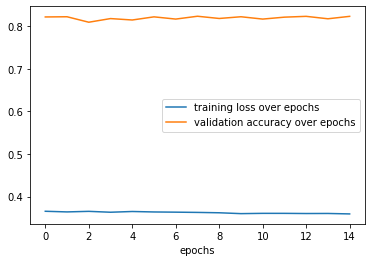

In [131]:
# Plot training loss and validation loss over epochs
sns.lineplot(x=range(15), y=history.history['loss'], label='training loss over epochs')
sns.lineplot(x=range(15), y=history.history['val_accuracy'], label='validation accuracy over epochs')
plt.xlabel("epochs")
plt.legend()
plt.show()

### Step 7: Evaluate the Model's Performance on the Test Set

<b>Task:</b> Use your neural network to generate predictions on the test set and evaluate its performance using accuracy and F1 score. Use `nn_model.predict()` to generate predictions. Since `nn_model.predict()` returns probabilities, apply a threshold of 0.5 to convert probabilities into binary class predictions before computing your metrics. Save your accuracy and F1 score results to clearly named variables so you can compare them to the results from your previous model. Print the results.

In [132]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels
prediction = nn_model.predict(X_test_scaled) > 0.5
print(prediction)

[[False]
 [False]
 [False]
 ...
 [False]
 [ True]
 [False]]


In [135]:
# Compute accuracy and F1 score for the neural network and print the results
from sklearn.metrics import accuracy_score, f1_score
acc_score_nn = accuracy_score(y_test, prediction)
f1_nn = f1_score(y_test, prediction)
print(str(acc_score) + " " + str(f1))

0.8180131316014845 0.588311268969971


#### Neural Network Reflection:

<b>Task:</b> In the markdown cell below, answer the following questions:

1. Walk through the architecture decisions you made: number of layers, number of units, activation functions, learning rate, and number of epochs. Why did you make each of those choices?
2. What did your training curves tell you? Did you see any signs of overfitting or underfitting?
3. How did your neural network perform on the test set? Report your accuracy and F1 score here and note whether the result surprised you given what your training curves showed.

1. I chose a neural network architecture with three hidden layers containing 128, 64, and 32 units. I started with a smaller architecture (64-32-16), but the larger architecture achieved better accuracy, so I increased the number of units while gradually decreasing them between layers. This structure allows the model to learn more complex patterns in the Airbnb pricing data while reducing the number of parameters in later layers. 

For the hidden layers, I used the ReLU activation function because it is commonly effective for hidden layers in feedforward neural networks and helps the model learn nonlinear relationships. For the output layer, I used one neuron with a sigmoid activation function because this is a binary classification problem where the model needs to output a probability between 0 and 1.

I used stochastic gradient descent (SGD) with a learning rate of 0.1. I chose this learning rate after experimenting with different values, starting with a larger learning rate and planning to decrease it if training became unstable or did not improve. I trained the model for 15 epochs because increasing the number of epochs did not improve performance and 15 epochs provided a good balance between training time and accuracy.

2. The training curves showed that both training and validation loss decreased over time, while accuracy generally increased. The validation accuracy remained close to the training accuracy, which suggests that the model was generalizing well. There were no major signs of overfitting because the validation loss did not consistently increase while training loss decreased. There were also no strong signs of underfitting because the model achieved over 80% accuracy on both training and validation data.

3. On the test set, the neural network achieved an accuracy of approximately 81.1% and an F1 score of approximately 0.544. The higher accuracy compared to the logistic regression model was expected because neural networks can capture more complex nonlinear relationships between features. However, the F1 score was slightly lower than expected, suggesting that the model may still struggle with identifying the minority high-price class due to class imbalance in the dataset.

## Part 7: Compare Your Models and Reflect

You have now applied two different approaches to the same problem. In this final section, you will put those results side by side and reflect on what you learned.

###  Results Summary

<b>Task:</b> In the code cell below, create a summary table using a Pandas DataFrame that displays each evaluation metric for both models side by side. Use the variables you created for the accuracy and F1 score metrics. The table should make it easy to compare performance at a glance across every metric you computed.

In [140]:
# Build a side-by-side comparison of your two models using the metric variables
# you created. For example:
#
# results = pd.DataFrame({
#     'Metric': ['Accuracy', 'F1 Score'],
#     'KNN Model': [knn_accuracy, knn_f1],
#     'Neural Network': [nn_accuracy, nn_f1]
# })
# print(results.to_string(index=False))

results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score'],
    'Logistic Regression': [acc_score, f1],
    'Neural Network': [acc_score_nn, f1_nn]
})

print(results.to_string(index=False))

   Metric  Logistic Regression  Neural Network
 Accuracy             0.731373        0.818013
 F1 Score             0.580660        0.588311


### Comparative Analysis

<b>Task:</b> In the markdown cell below, write a comparative analysis that addresses the following. 

1. **Performance comparison.** How did the two models perform relative to each other? Which metrics improved, which stayed the same, and which got worse?

2. **Was the added complexity worth it?** Neural networks are more complex to build, tune, and interpret. Given the performance difference you observed, do you think the neural network justified that added complexity for this problem?

3. **Recommendation.** If you were presenting this work to your company and their client as described in the business brief, which model would you recommend deploying and why? Consider not just performance but also interpretability, training time, and what the costs of different types of errors look like for that specific client.

4. **What you would do next.** If you had more time, what would you try to improve your results? This could include trying different architectures, additional preprocessing steps, different features, or techniques to address class imbalance. Be specific.

The neural network performed better than the logistic regression model on both evaluation metrics. The neural network improved accuracy from 73.1% to 81.8% and improved the F1 score from 0.581 to 0.588. This shows that the neural network was able to capture more complex patterns in the Airbnb pricing data and slightly improved its ability to identify high-priced listings. Since both accuracy and F1 score improved, neither metric became worse when moving to the neural network.

The added complexity of the neural network was somewhat worth it for this problem because it provided better overall performance. However, the improvement in F1 score was relatively small compared to the increased complexity, training time, and reduced interpretability. Logistic regression provides easier-to-understand coefficients that explain which features influence predictions, while neural networks act more like a black box. For this dataset, the performance improvement is useful, but the tradeoff between accuracy and explainability should be considered.

If presenting this work to the company and their client, I would recommend deploying the neural network model because it achieved better predictive performance and would likely provide more accurate price category predictions for Airbnb listings. Since incorrect predictions could cause hosts to underprice or overprice their listings, improving prediction accuracy can help the company make better pricing decisions. However, I would also consider keeping the logistic regression model as a baseline because its predictions are easier to explain to stakeholders and debug.

If I had more time, I would focus on improving the model by performing additional feature engineering and addressing class imbalance. I would experiment with adding more location-based features, since neighborhood is likely a strong factor in Airbnb pricing. I would also try techniques such as adjusting class weights, oversampling the minority high-price class, and tuning the classification threshold to further improve the F1 score. Additionally, I would experiment with different neural network architectures, optimizers such as dropout layers or hyperparameter tuning to find a model that generalizes even better.

---
## AI Use Attestation

Reflect honestly on how you used AI tools during this capstone. You are expected to have used AI somewhere in your workflow, and your reflection on that use is what will be evaluated: How clearly you describe your choices, how you verified your work, and what you learned from the process. If you chose not to use AI, explain why. Answer each question in the markdown cell below.

1. Where and at what stages of this capstone did you use AI tools, for example, Claude during brainstorming, coding, or debugging? If you chose not to use AI, explain why.
2. Identify one part of the capstone that required the most effort or thought. What made it challenging, and how did you work through it, with AI or without AI? If you used AI at this point, feel free to share a prompt that worked well or one that did not land the way you expected.
3. How did you verify that your work was correct? What did you look for to catch a mistake, whether it came from AI output or your own reasoning?
4. What is one thing you would do differently next time, either in how you approached the capstone or in how you used AI during it?

1. I used AI tools throughout the capstone as a learning and debugging resource. I primarily used AI during the coding and analysis stages to help understand errors, review machine learning concepts, and improve my explanations of modeling decisions. For example, I used AI to help debug issues with neural network predictions, evaluation metrics, plotting training curves, and understanding how preprocessing choices affected model performance. I also used AI to brainstorm possible improvements to the models, such as addressing class imbalance and tuning hyperparameters.

2. The most challenging part of the capstone was preparing the data and improving the logistic regression model. The dataset contained missing values, categorical features, and an imbalanced target variable, which required careful decisions about feature selection, encoding, scaling, and evaluation metrics. I worked through these challenges by experimenting with different preprocessing methods, comparing model performance, and using AI to clarify concepts when I encountered errors. One useful prompt was asking for help interpreting model performance and identifying ways to improve the F1 score given that the dataset was imbalanced.

3. I verified my work by checking that my code produced expected outputs and by comparing model results across different approaches. I reviewed evaluation metrics such as accuracy and F1 score, examined training and validation curves for signs of overfitting or underfitting, and confirmed that predictions were converted correctly from probabilities into binary labels. I also tested changes incrementally rather than relying only on AI-generated suggestions, ensuring that I understood why each modification improved or affected the model.

4. One thing I would do differently next time is incorporate more systematic experimentation earlier in the process. Instead of making changes one at a time after encountering issues, I would create a more structured plan for testing different features, preprocessing techniques, and model architectures. I would also use AI earlier as a brainstorming partner for feature engineering ideas and experiment design, rather than mainly using it for debugging after problems occurred.